In [17]:
import pandas as pd

BASE_PATH = "../dataset/elliptic/elliptic_bitcoin_dataset/"

features = pd.read_csv(
    BASE_PATH + "elliptic_txs_features.csv",
    header=None
)

classes = pd.read_csv(
    BASE_PATH + "elliptic_txs_classes.csv"
)

edges = pd.read_csv(
    BASE_PATH + "elliptic_txs_edgelist.csv"
)

print("Features Shape:", features.shape)
print("Classes Shape:", classes.shape)
print("Edges Shape:", edges.shape)

Features Shape: (203769, 167)
Classes Shape: (203769, 2)
Edges Shape: (234355, 2)


In [19]:
print(classes['class'].value_counts())

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


In [20]:
features.columns = ['txId'] + [f'feature_{i}' for i in range(166)]

df = features.merge(classes, on='txId')

print(df.head())

        txId  feature_0  feature_1  feature_2  feature_3  feature_4  \
0  230425980          1  -0.171469  -0.184668  -1.201369  -0.121970   
1    5530458          1  -0.171484  -0.184668  -1.201369  -0.121970   
2  232022460          1  -0.172107  -0.184668  -1.201369  -0.121970   
3  232438397          1   0.163054   1.963790  -0.646376  12.409294   
4  230460314          1   1.011523  -0.081127  -1.201369   1.153668   

   feature_5  feature_6  feature_7  feature_8  ...  feature_157  feature_158  \
0  -0.043875  -0.113002  -0.061584  -0.162097  ...    -0.600999     1.461330   
1  -0.043875  -0.113002  -0.061584  -0.162112  ...     0.673103    -0.979074   
2  -0.043875  -0.113002  -0.061584  -0.162749  ...     0.439728    -0.979074   
3  -0.063725   9.782742  12.414558  -0.163645  ...    -0.613614     0.241128   
4   0.333276   1.312656  -0.061584  -0.163523  ...    -0.400422     0.517257   

   feature_159  feature_160  feature_161  feature_162  feature_163  \
0     1.461369     0.0

In [21]:
illicit = df[df['class'] == '1']

print(illicit.shape)

(4545, 168)


In [28]:
import networkx as nx

G = nx.from_pandas_edgelist(
    edges,
    source='txId1',
    target='txId2'
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 203769
Edges: 234355


In [30]:
sample_edges = edges.head(1000)

small_g = nx.from_pandas_edgelist(
    sample_edges,
    source='txId1',
    target='txId2'
)

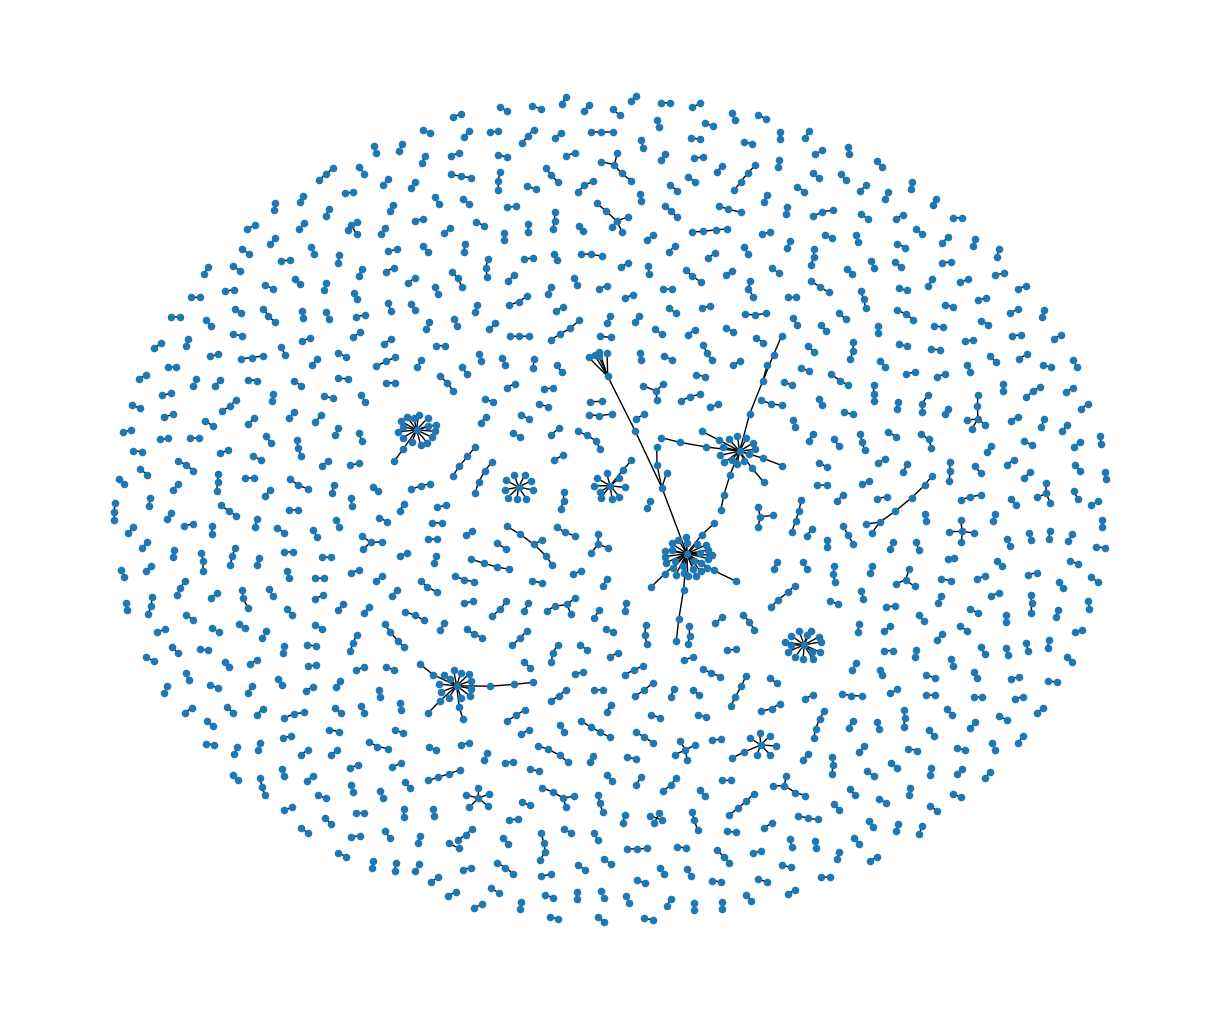

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

nx.draw(
    small_g,
    node_size=20,
    with_labels=False
)

plt.show()

In [34]:
illicit_ids = set(
    classes[classes['class'] == '1']['txId']
)

In [35]:
sample_edges = edges.head(1000)

small_g = nx.from_pandas_edgelist(
    sample_edges,
    source='txId1',
    target='txId2'
)

In [36]:
node_colors = []

for node in small_g.nodes():
    if node in illicit_ids:
        node_colors.append("red")
    else:
        node_colors.append("skyblue")

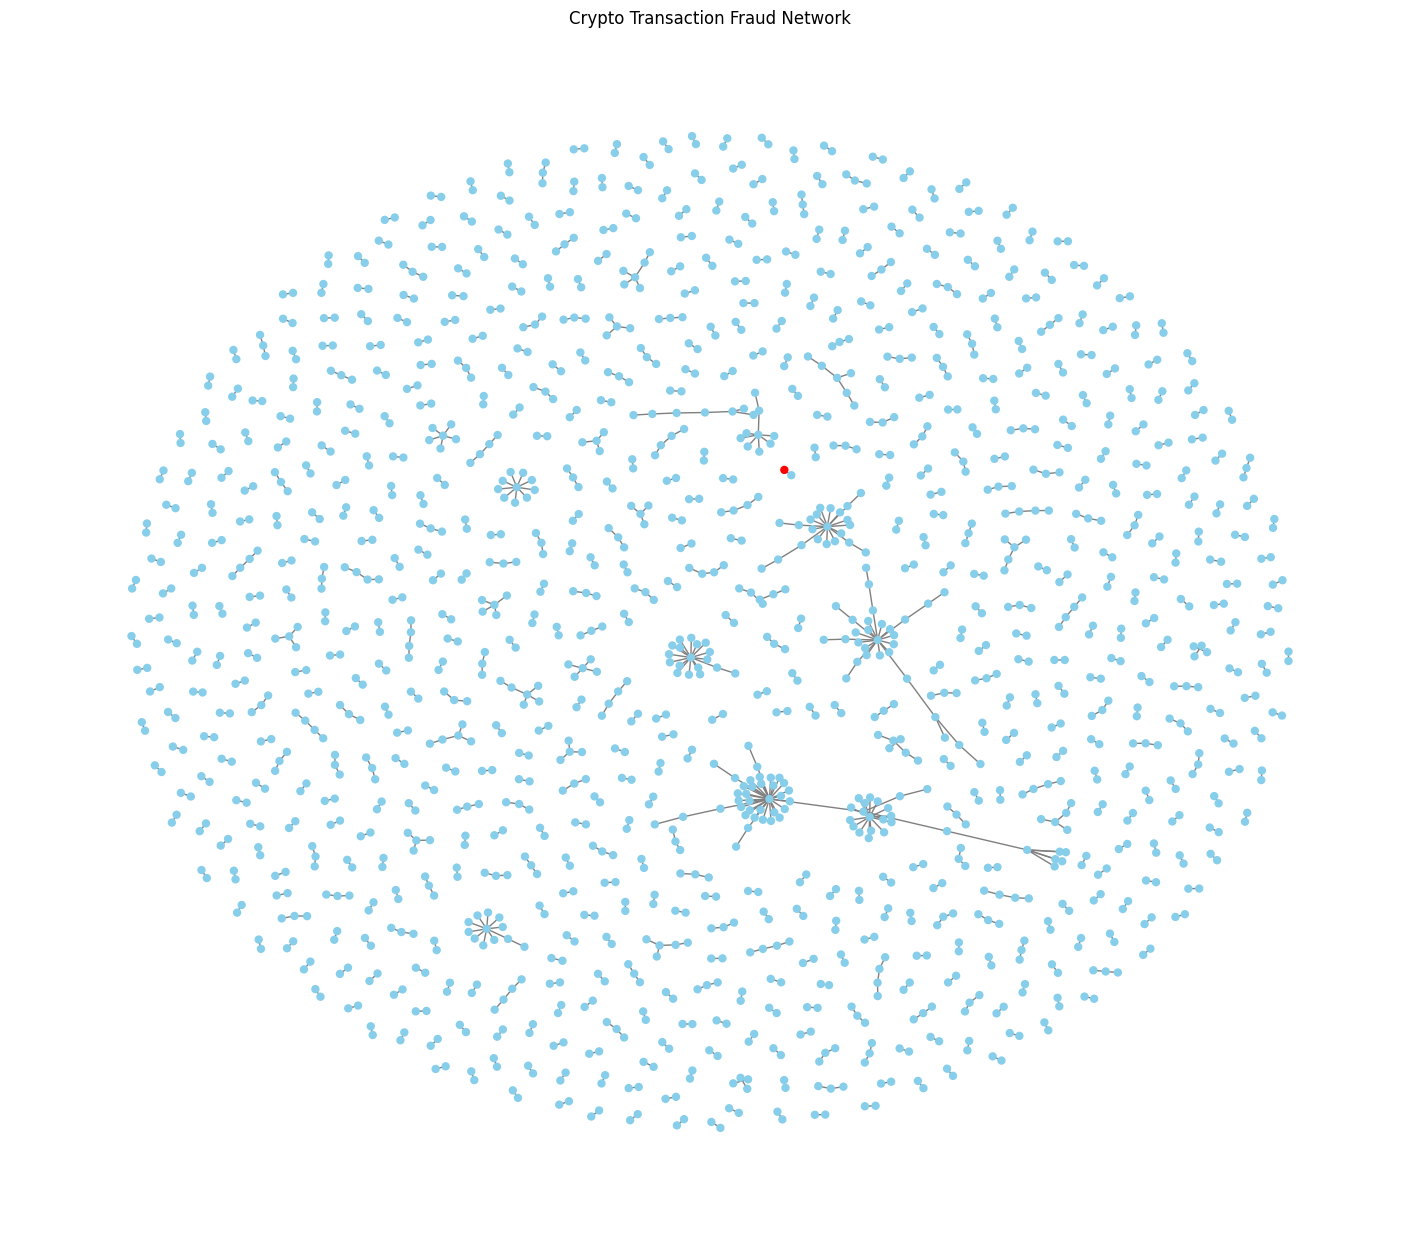

In [37]:
plt.figure(figsize=(14,12))

pos = nx.spring_layout(
    small_g,
    seed=42
)

nx.draw(
    small_g,
    pos,
    node_color=node_colors,
    node_size=25,
    with_labels=False,
    edge_color="gray"
)

plt.title("Crypto Transaction Fraud Network")

plt.show()

Graph Centrality Analysis

In [38]:
centrality = nx.degree_centrality(small_g)

top_nodes = sorted(
    centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

top_nodes

[(89273, 0.01848539057841383),
 (2881273, 0.01073345259391771),
 (2758467, 0.009540846750149075),
 (2881274, 0.009540846750149075),
 (230658142, 0.008348240906380441),
 (232438397, 0.005963029218843172),
 (43560505, 0.005366726296958855),
 (232029206, 0.0041741204531902205),
 (1913117, 0.0035778175313059034),
 (2880930, 0.002981514609421586)]

In [39]:
import pandas as pd

centrality_df = pd.DataFrame(
    top_nodes,
    columns=['Transaction', 'Centrality']
)

centrality_df

,Transaction,Centrality
0,89273,0.018485
1,2881273,0.010733
2,2758467,0.009541
3,2881274,0.009541
4,230658142,0.008348
5,232438397,0.005963
6,43560505,0.005367
7,232029206,0.004174
8,1913117,0.003578
9,2880930,0.002982


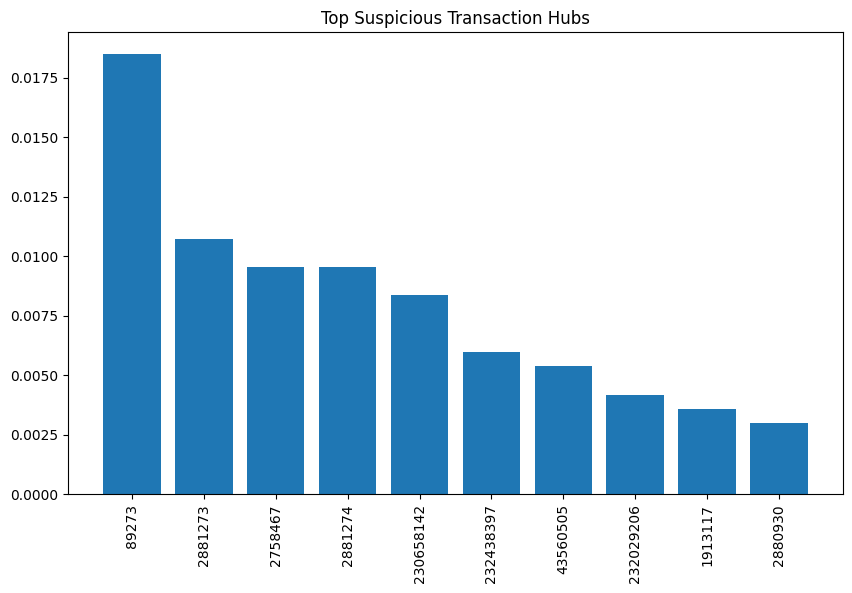

In [45]:
plt.figure(figsize=(10,6))

plt.bar(
    centrality_df['Transaction'].astype(str),
    centrality_df['Centrality']
)

plt.xticks(rotation=90)

plt.title("Top Suspicious Transaction Hubs")

plt.show()

Risk Intelligence

In [43]:
risk_scores = []

for node in small_g.nodes():
    
    centrality_score = centrality.get(node, 0)
    
    fraud_connection_score = 1 if node in illicit_ids else 0
    
    risk_score = (
        centrality_score * 0.7 +
        fraud_connection_score * 0.3
    )
    
    risk_scores.append({
        "transaction": node,
        "risk_score": risk_score
    })

risk_df = pd.DataFrame(risk_scores)

risk_df.head()

,transaction,risk_score
0,230425980,0.000417
1,5530458,0.000417
2,232022460,0.000835
3,232438397,0.004174
4,230460314,0.000835


In [46]:
centrality_df.to_csv(
    "../dataset/centrality_results.csv",
    index=False
)

In [48]:
from networkx.algorithms.community import greedy_modularity_communities
communities = greedy_modularity_communities(small_g)

print("Number of Communities:", len(communities))

Number of Communities: 678


In [50]:
community_sizes = [len(c) for c in communities]

community_df = pd.DataFrame({
    "community_id": range(len(community_sizes)),
    "size": community_sizes
})

community_df.sort_values(
    by="size",
    ascending=False
).head()

,community_id,size
0,0,47
1,1,30
2,2,22
3,3,18
4,4,15


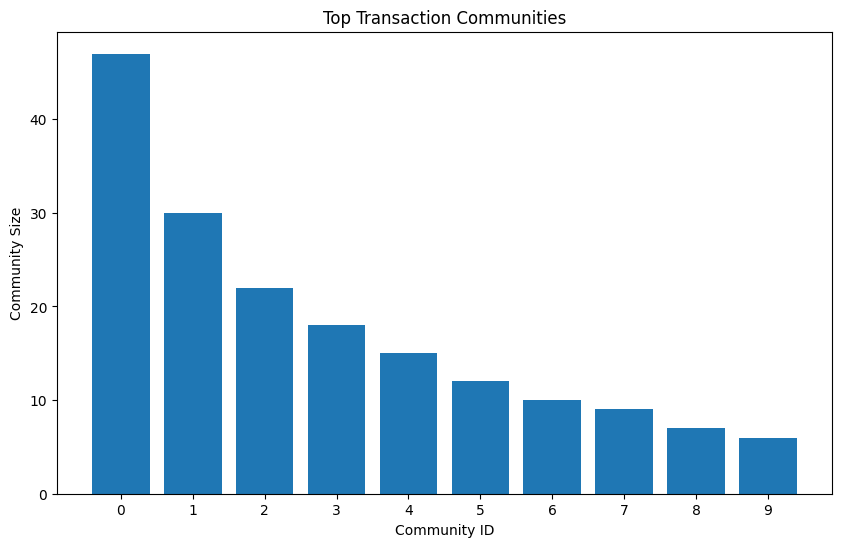

In [51]:
plt.figure(figsize=(10,6))

plt.bar(
    community_df['community_id'][:10].astype(str),
    community_df['size'][:10]
)

plt.title("Top Transaction Communities")

plt.xlabel("Community ID")
plt.ylabel("Community Size")

plt.show()

 Anomaly Detection

In [54]:
from sklearn.ensemble import IsolationForest
X = df.drop(columns=['txId', 'class'])

In [55]:
model = IsolationForest(
    contamination=0.02,
    random_state=42
)

model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [56]:
df['anomaly'] = model.predict(X)
df['anomaly'] = df['anomaly'].map({
    -1: 1,
     1: 0
})

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22508\3144964499.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anomaly'] = model.predict(X)


In [57]:
df['anomaly'].value_counts()

anomaly
0    199693
1      4076
Name: count, dtype: int64

In [58]:
anomalies = df[df['anomaly'] == 1]

anomalies.head()

,txId,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class,anomaly
44,232033533,1,-0.156114,-0.184668,-1.201369,-0.046932,-0.043875,-0.02914,-0.061584,-0.161356,...,0.241128,0.241406,-0.098889,-0.08749,-0.084674,-0.140597,1.519700,1.521399,2,1
141,51860219,1,-0.158314,-0.184668,-1.201369,-0.046932,-0.043875,-0.02914,-0.061584,-0.157837,...,-0.979074,-0.978556,-0.098889,-0.08749,-0.084674,-0.140597,1.519700,1.521399,2,1
177,40297647,1,-0.163213,-0.184668,-1.201369,-0.046932,-0.043875,-0.02914,-0.061584,-0.161394,...,1.461330,1.461369,-0.098889,-0.08749,-0.084674,-0.140597,-1.760926,-1.760984,2,1
185,232468876,1,-0.172391,-0.158783,-1.201369,0.028105,-0.043875,-0.02914,0.242712,-0.163601,...,1.461330,1.461369,-0.098889,-0.08749,-0.084674,-0.140597,1.519700,1.521399,2,1
252,232440137,1,-0.154627,-0.184668,-1.201369,-0.046932,-0.043875,-0.02914,-0.061584,-0.159743,...,0.241128,0.241406,0.018279,-0.08749,-0.131155,-0.097524,-0.120613,-0.119792,2,1


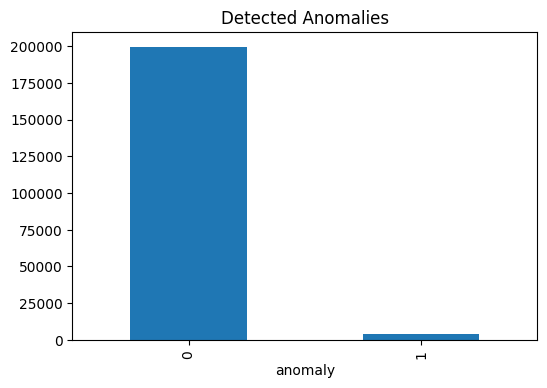

In [59]:
plt.figure(figsize=(6,4))

df['anomaly'].value_counts().plot(
    kind='bar'
)

plt.title("Detected Anomalies")

plt.show()

EXPORT ANOMALIES

In [60]:
anomalies.to_csv(
    "../dataset/anomalies.csv",
    index=False
)

In [61]:
community_df.to_csv(
    "../dataset/community_analysis.csv",
    index=False
)

In [62]:
risk_df.to_csv(
    "../dataset/risk_scores.csv",
    index=False
)

In [63]:
centrality_df.to_csv(
    "../dataset/centrality_results.csv",
    index=False
)

In [64]:
sample_edges = edges.head(100)

sample_edges.to_csv(
    "../backend/app/data/sample_edges.csv",
    index=False
)